In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from scipy.spatial.distance import cdist # Nearest neighbor classification
import altair as alt


### Load ATT Faces Dataset

Training set: 360 images, Test set: 40 images
Image size: (112, 92)
Training matrix: (360, 10304), Test matrix: (40, 10304)


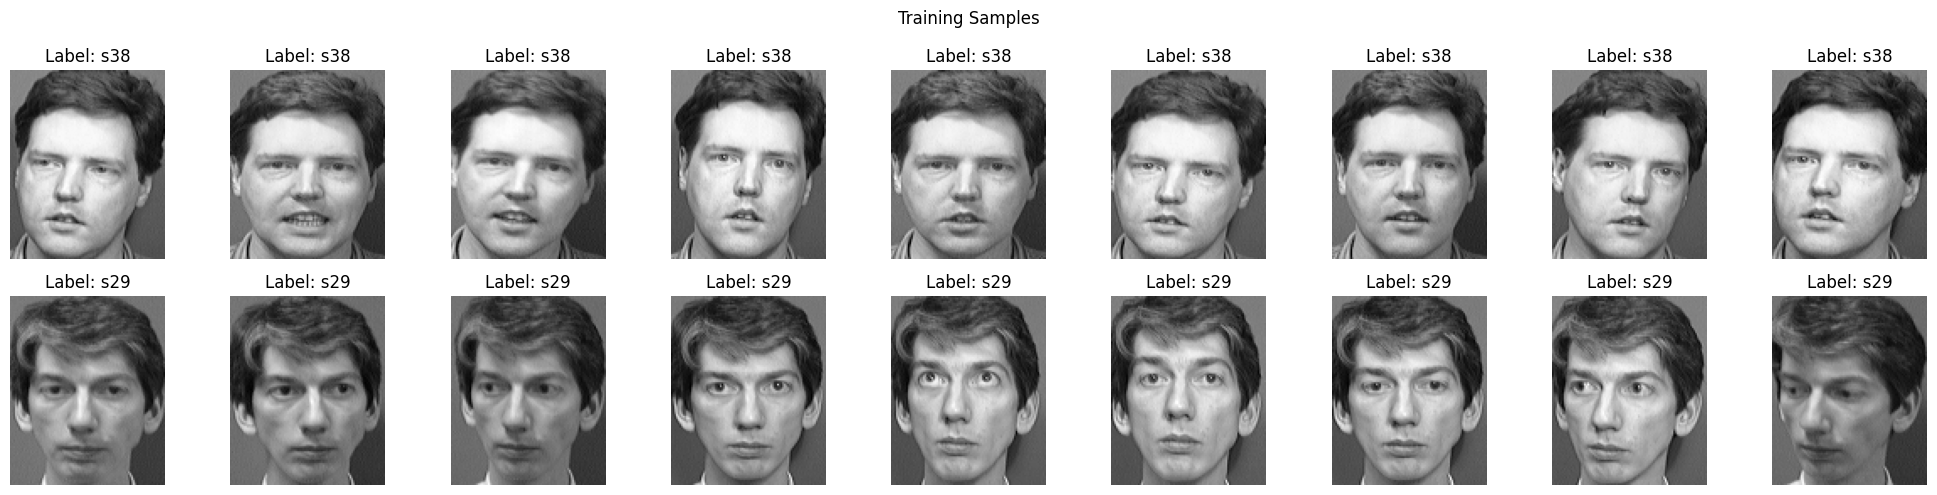

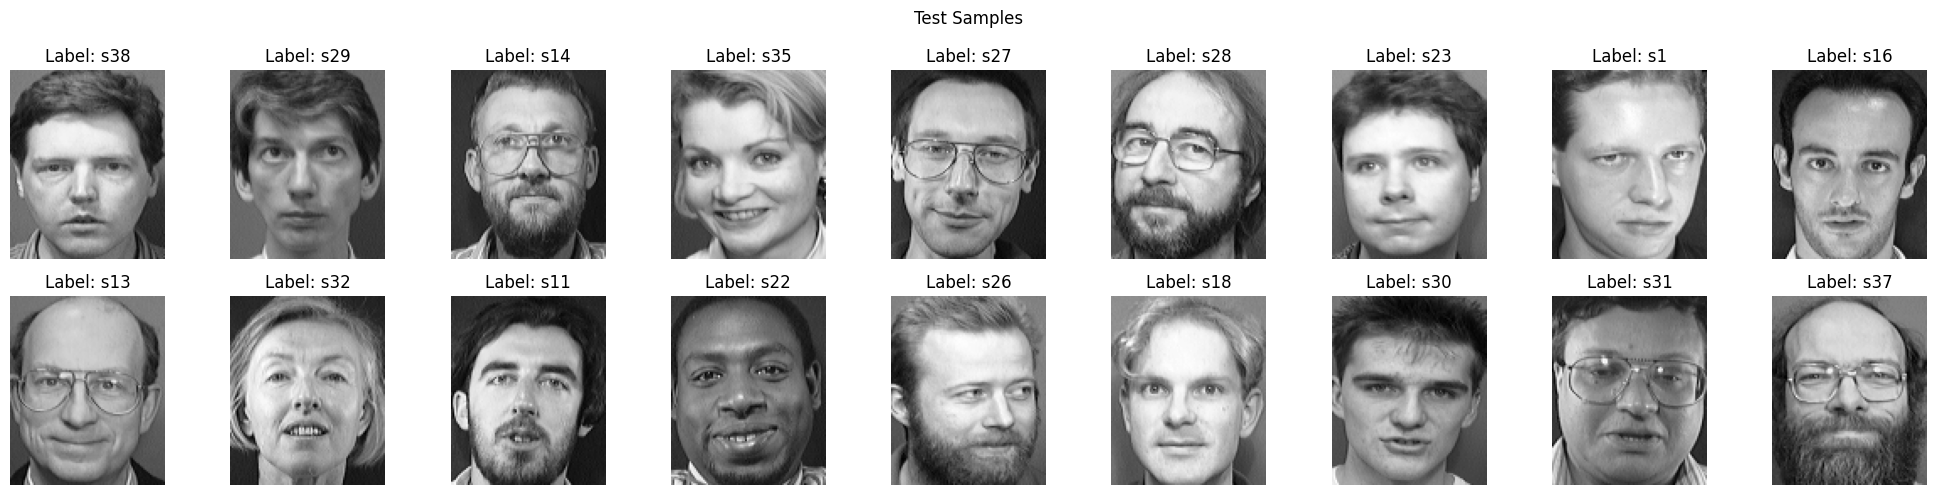

In [2]:
def load_images(path):
    images, labels = [], []
    for root, dirs, files in os.walk(path):
        for f in sorted(files):
            if f.endswith('.pgm'):
                img = Image.open(os.path.join(root, f))
                images.append(np.array(img, dtype=np.float64))
                labels.append(os.path.basename(root))  
    return images, labels

train_imgs, train_labels = load_images("Datasets/att_faces/Training")
test_imgs, test_labels = load_images("Datasets/att_faces/Testing")

print(f"Training set: {len(train_imgs)} images, Test set: {len(test_imgs)} images")
print(f"Image size: {train_imgs[0].shape}")

# Flatten into matrix (each row = one image)
X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize samples
fig, axes = plt.subplots(2, 9, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(train_imgs[i], cmap='gray')
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 9, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(test_imgs[i], cmap='gray')
    ax.set_title(f"Label: {test_labels[i]}")
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

### 

### PCA Method for Face Recognition

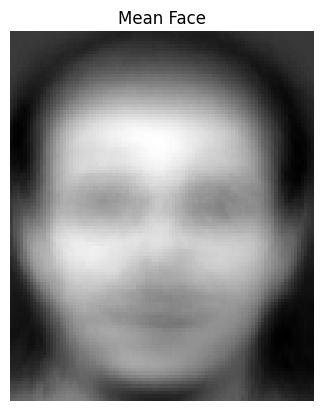

In [3]:
# Compute mean face 
mean_face = np.mean(X_train, axis=0)

# Visualize mean face
plt.imshow(mean_face.reshape(112, 92), cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()



In [4]:
# Center the data
X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

Covariance matrix shape: (360, 360)


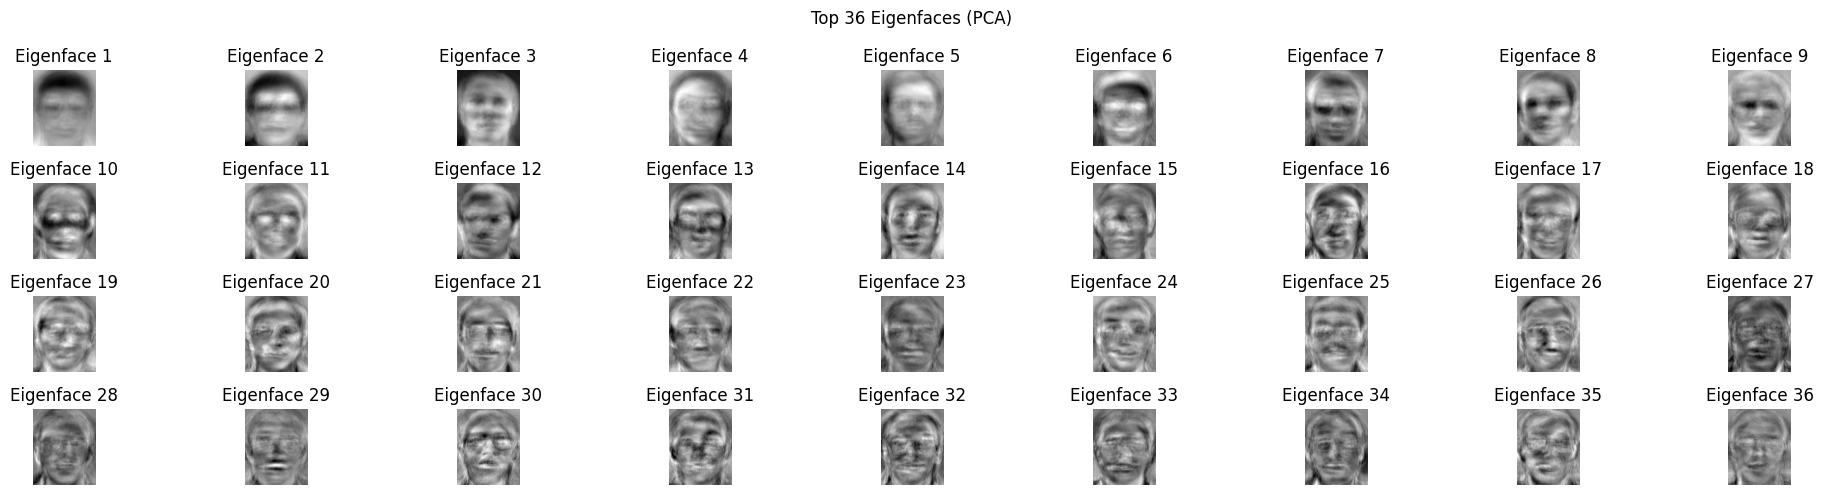

In [5]:
# Compute covariance matrix 
n = X_train_centered.shape[0]
cov_matrix = (X_train_centered @ X_train_centered.T) / (n - 1)
print(f"Covariance matrix shape: {cov_matrix.shape}")

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by eigenvalue descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
small_eigvecs = eigenvectors[:, idx]

eigenvectors = X_train_centered.T @ small_eigvecs  # (10304, 360)
# Normalize each eigenvector to unit length
eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

# Visualize top eigenfaces
fig, axes = plt.subplots(4, 9, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(eigenvectors[:, i].reshape(112, 92), cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
plt.suptitle("Top 36 Eigenfaces (PCA)")
plt.tight_layout()
plt.show()

Components needed for 95% variance: 176


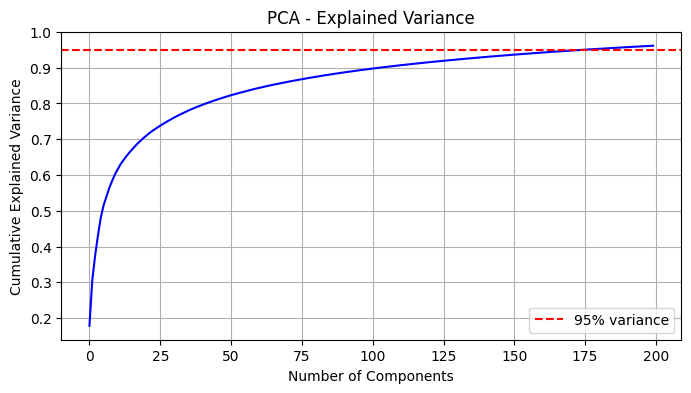

In [6]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {k_95}")

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance[:200], 'b-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

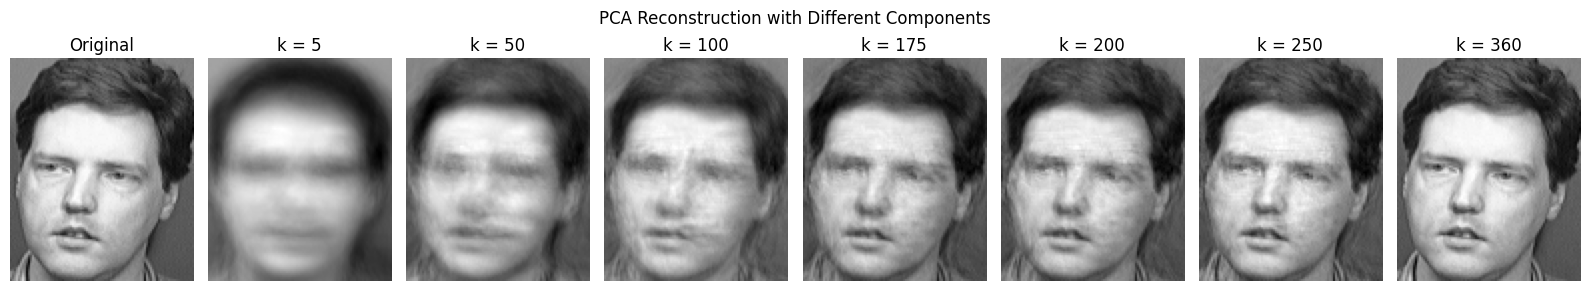

In [7]:
components_list = [5, 50, 100, 175, 200, 250, 360]
sample_idx = 0  # Choose which training face to reconstruct
fig, axes = plt.subplots(1, len(components_list) + 1, figsize=(16, 3))

# Show original face
axes[0].imshow(train_imgs[sample_idx], cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

# Show reconstructions at different k values
for j, k in enumerate(components_list):
    W = eigenvectors[:, :k]                          
    projected = X_train_centered[sample_idx] @ W     
    reconstructed = projected @ W.T + mean_face     
    axes[j+1].imshow(reconstructed.reshape(112, 92), cmap='gray')
    axes[j+1].set_title(f"k = {k}")
    axes[j+1].axis('off')

plt.suptitle("PCA Reconstruction with Different Components")
plt.tight_layout()
plt.show()

In [8]:
# Compare PCA Recognition Accuracy at Different k Values & Mertrics

k_list = [1,10,50,100,176,250,360]

print("=== Euclidean Distance ===")
for k in k_list:
    W = eigenvectors[:, :k]
    X_train_proj = X_train_centered @ W
    X_test_proj = X_test_centered @ W

    distances = cdist(X_test_proj, X_train_proj, metric='euclidean')
    preds = y_train[np.argmin(distances, axis=1)]
    acc = np.mean(preds == y_test)
    print(f"k = {k:>3d} | Accuracy: {acc * 100:.2f}%")

print("\n===Mahalanobis Distance ===")
for k in k_list:
    W = eigenvectors[:, :k]
    X_train_proj = X_train_centered @ W
    X_test_proj = X_test_centered @ W

    distances = cdist(X_test_proj, X_train_proj, metric='mahalanobis')
    preds = y_train[np.argmin(distances, axis=1)]
    acc = np.mean(preds == y_test)
    print(f"k = {k:>3d} | Accuracy: {acc * 100:.2f}%")

print("\n=== Cosine Similarity ===")
for k in k_list:
    W = eigenvectors[:, :k]
    X_train_proj = X_train_centered @ W
    X_test_proj = X_test_centered @ W

    distances = cdist(X_test_proj, X_train_proj, metric='cosine')
    preds = y_train[np.argmin(distances, axis=1)]
    acc = np.mean(preds == y_test)
    print(f"k = {k:>3d} | Accuracy: {acc * 100:.2f}%")
    

=== Euclidean Distance ===
k =   1 | Accuracy: 10.00%
k =  10 | Accuracy: 92.50%
k =  50 | Accuracy: 95.00%
k = 100 | Accuracy: 95.00%
k = 176 | Accuracy: 92.50%
k = 250 | Accuracy: 92.50%
k = 360 | Accuracy: 92.50%

===Mahalanobis Distance ===
k =   1 | Accuracy: 10.00%
k =  10 | Accuracy: 90.00%
k =  50 | Accuracy: 87.50%


k = 100 | Accuracy: 85.00%
k = 176 | Accuracy: 72.50%
k = 250 | Accuracy: 50.00%
k = 360 | Accuracy: 72.50%

=== Cosine Similarity ===
k =   1 | Accuracy: 5.00%
k =  10 | Accuracy: 92.50%
k =  50 | Accuracy: 95.00%
k = 100 | Accuracy: 95.00%
k = 176 | Accuracy: 95.00%
k = 250 | Accuracy: 95.00%
k = 360 | Accuracy: 95.00%


In [9]:
k_list = [1] + list(range(10, 361, 10))
metrics = ['euclidean', 'cosine', 'mahalanobis']
rows = []

for metric in metrics:
    for k in k_list:
        W = eigenvectors[:, :k]
        X_train_proj = X_train_centered @ W
        X_test_proj = X_test_centered @ W

        if metric == 'mahalanobis':
            cov = np.cov(X_train_proj, rowvar=False)

            VI = np.linalg.pinv(np.atleast_2d(cov))
            distances = cdist(X_test_proj, X_train_proj, metric='mahalanobis', VI=VI)
        else:
            distances = cdist(X_test_proj, X_train_proj, metric=metric)

        preds = y_train[np.argmin(distances, axis=1)]
        acc = np.mean(preds == y_test)  

        rows.append({
            'k': k,
            'Metric': metric.capitalize(),
            'Accuracy': acc
        })

df = pd.DataFrame(rows)

input_dropdown = alt.binding_select(
    options=[None, 'Euclidean', 'Cosine', 'Mahalanobis'],
    labels=['All', 'Euclidean', 'Cosine', 'Mahalanobis'],
    name='Metric: '
)

selection = alt.selection_point(fields=['Metric'], bind=input_dropdown)

chart = alt.Chart(df).mark_line(interpolate='monotone').encode(
    x=alt.X(
        'k:Q',
        title='Number of Components (k)',
        scale=alt.Scale(domain=[1, 360]),
        axis=alt.Axis(values=[1] + list(range(10, 361, 10)))
    ),
    y=alt.Y(
        'Accuracy:Q',
        title='Accuracy',
        axis=alt.Axis(format='%'),
        scale=alt.Scale(domain=[0, 1])
    ),
    color=alt.Color('Metric:N', title='Distance Metric'),
    tooltip=[
        alt.Tooltip('Metric:N'),
        alt.Tooltip('k:Q'),
        alt.Tooltip('Accuracy:Q', format='.2%')
    ],
    opacity=alt.condition(selection, alt.value(1), alt.value(0.15))
).add_params(
    selection
).properties(
    title='PCA Recognition Accuracy by Different Distance Metrics',
    width=800,
    height=400
)

chart

alt.Chart(...)

Projected training data: (360, 176)
Projected test data: (40, 176)

PCA Recognition Accuracy: 92.50%


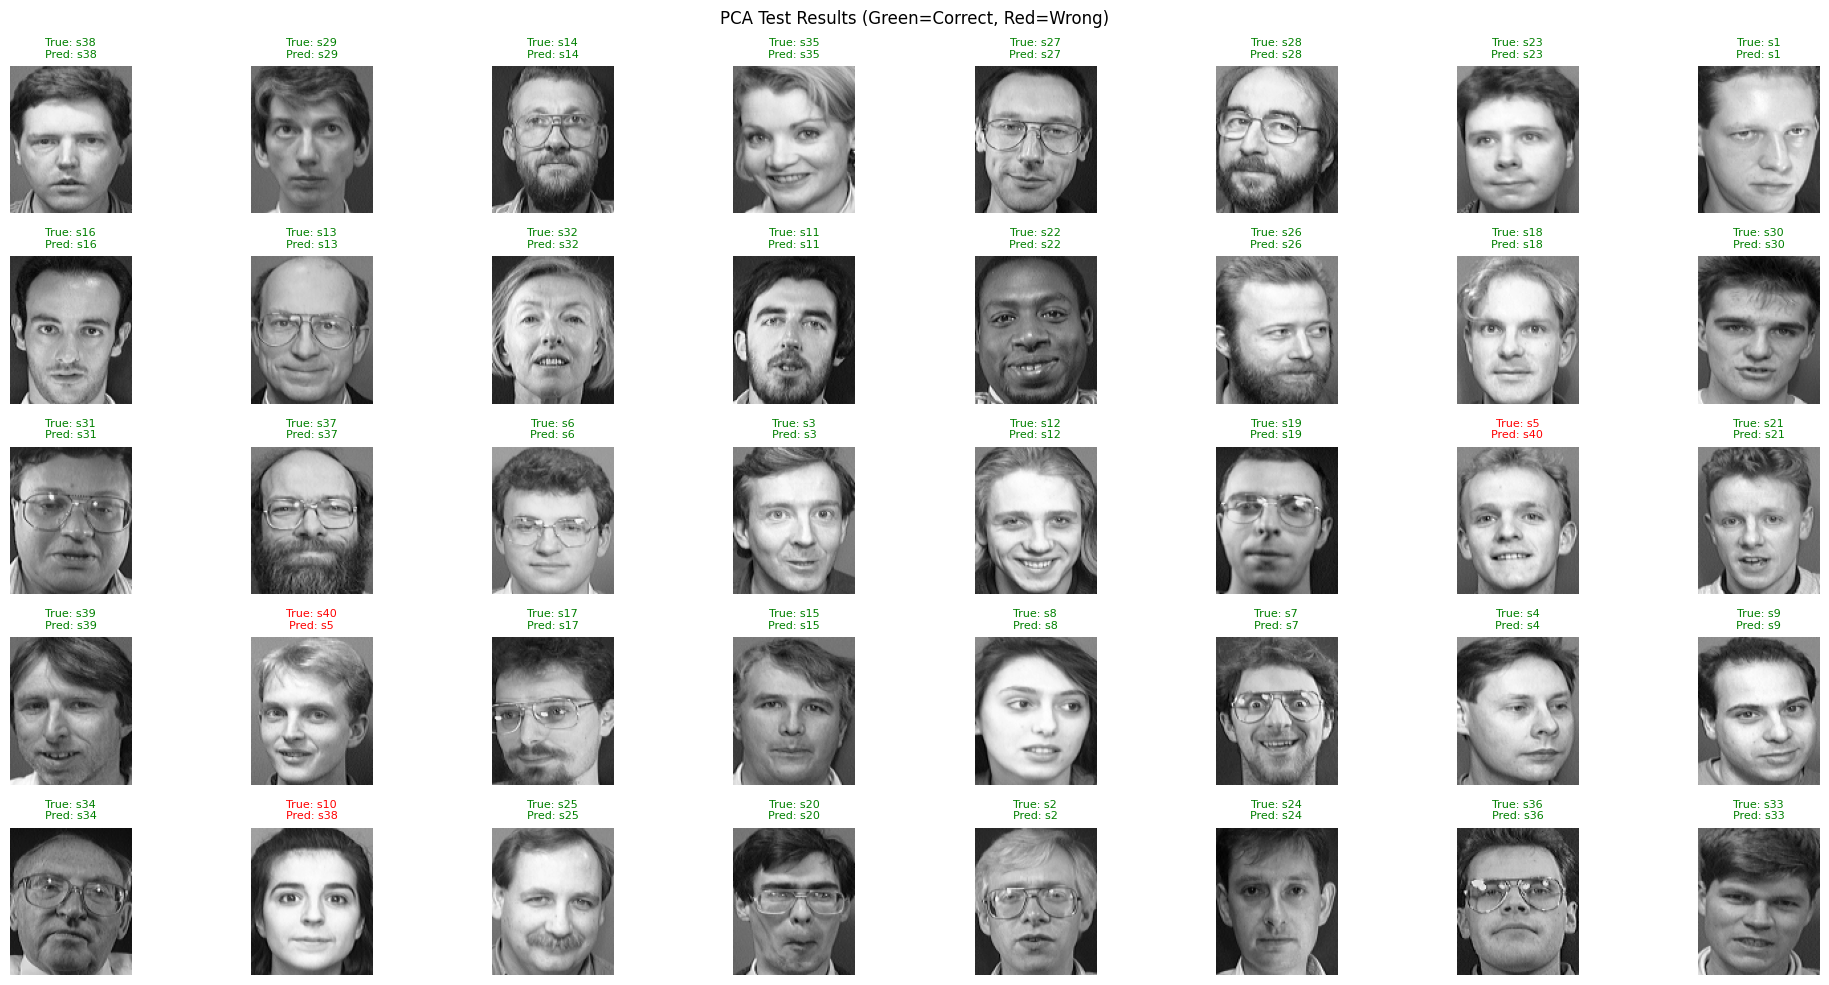

In [10]:
# Project data to lower dimension(example)
k = k_95 
W_pca = eigenvectors[:, :k]  

X_train_pca = X_train_centered @ W_pca  # (360, 10304) × (10304, k) = (360, k)
X_test_pca = X_test_centered @ W_pca    # (40, 10304) × (10304, k) = (40, k)

print(f"Projected training data: {X_train_pca.shape}")
print(f"Projected test data: {X_test_pca.shape}")

distances = cdist(X_test_pca, X_train_pca, metric='euclidean')
predictions = y_train[np.argmin(distances, axis=1)]

accuracy = np.mean(predictions == y_test)
print(f"\nPCA Recognition Accuracy: {accuracy * 100:.2f}%")

# Show test results
fig, axes = plt.subplots(5, 8, figsize=(20, 10))

for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        color = 'green' if predictions[i] == y_test[i] else 'red'
        ax.set_title(f"True: {y_test[i]}\nPred: {predictions[i]}", fontsize=8, color=color)
    ax.axis('off')
plt.suptitle("PCA Test Results (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

In [11]:
df

,k,Metric,Accuracy
0,1,Euclidean,0.100
1,10,Euclidean,0.925
2,20,Euclidean,0.950
3,30,Euclidean,0.950
4,40,Euclidean,0.950
...,...,...,...
106,320,Mahalanobis,0.600
107,330,Mahalanobis,0.600
108,340,Mahalanobis,0.650
109,350,Mahalanobis,0.650
